### Additional Memory Management Tips

**When to clear memory:**
- After training/evaluation before starting a new notebook
- When switching between large models
- If you get CUDA out of memory errors

**What gets cleared:**
- `del model` - Removes Python reference to model
- `gc.collect()` - Frees Python objects from memory
- `torch.cuda.empty_cache()` - Releases cached GPU memory back to system

**Checking memory usage:**
```python
# See current GPU memory usage
!nvidia-smi

# Or in Python:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print(f"Max allocated: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
```

**Note:** After clearing memory, you'll need to reload the models if you want to use them again.

## Introduction

In previous notebooks, we built specialized VLMs:
1. [Caption model](2025-12-24-minimal-VLM-Mastery.html) - describes images
2. [Object detection model](2025-12-25-vlm-instruction-tuning-od.html) - outputs JSON with bounding boxes
3. [VQA model](2025-12-25-vlm-vqa-instruction-tuning.html) - answers questions

Now, let's combine all three capabilities into **one unified multi-task model**. This is similar to how modern VLMs like GPT-4V, Gemini, and LLaVA handle multiple vision-language tasks.

### Multi-Task Model Benefits

- **Single model** handles multiple tasks
- **Shared representations** improve generalization
- **Task transfer** - learning one task helps others
- **More practical** - deploy one model instead of three

### Three Tasks in One Model

| Task | Input | Output |
|------|-------|--------|
| **Caption** | `"Describe this image."` | `"A dog playing in the park."` |
| **OD** | `"What objects? Output JSON."` | `{"objects": [{"label": "dog", "bbox": [...]}]}` |
| **VQA** | `"Question: What color? Answer:"` | `"brown"` |

## Setup

In [1]:
!uv pip install -q transformers datasets torch torchvision pillow accelerate einops timm supervision

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    ViTModel,
    ViTImageProcessor,
)
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import json
import textwrap
import random
import os
import warnings
warnings.filterwarnings('ignore')

import supervision as sv

%config InlineBackend.figure_format = 'retina'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/ShivamTheCodingDon/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Part 1: Load Base VLM Architecture

We'll start from the caption-trained model and fine-tune it on all three tasks simultaneously.

In [3]:
# Model architecture (same as before)

class VisionProjector(nn.Module):
    """Projects vision features into the language model's embedding space."""
    
    def __init__(self, vision_dim: int, language_dim: int):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(vision_dim, language_dim),
            nn.GELU(),
            nn.LayerNorm(language_dim),
            nn.Linear(language_dim, language_dim),
        )
    
    def forward(self, vision_features: torch.Tensor) -> torch.Tensor:
        return self.projection(vision_features)


class MiniVLM(nn.Module):
    """A minimal Vision-Language Model."""
    
    def __init__(
        self,
        vision_encoder: ViTModel,
        language_model: AutoModelForCausalLM,
        projector: VisionProjector,
        tokenizer: AutoTokenizer,
    ):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.language_model = language_model
        self.projector = projector
        self.tokenizer = tokenizer
        
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
    
    def encode_image(self, pixel_values: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            vision_outputs = self.vision_encoder(pixel_values=pixel_values)
        image_features = vision_outputs.last_hidden_state
        projected = self.projector(image_features)
        return projected
    
    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: torch.Tensor = None,
    ):
        batch_size = pixel_values.shape[0]
        image_embeds = self.encode_image(pixel_values)
        num_image_tokens = image_embeds.shape[1]
        
        text_embeds = self.language_model.get_input_embeddings()(input_ids)
        combined_embeds = torch.cat([image_embeds, text_embeds], dim=1)
        
        image_attention = torch.ones(
            (batch_size, num_image_tokens),
            dtype=attention_mask.dtype,
            device=attention_mask.device
        )
        combined_attention = torch.cat([image_attention, attention_mask], dim=1)
        
        if labels is not None:
            image_labels = torch.full(
                (batch_size, num_image_tokens),
                fill_value=-100,
                dtype=labels.dtype,
                device=labels.device
            )
            combined_labels = torch.cat([image_labels, labels], dim=1)
        else:
            combined_labels = None
        
        outputs = self.language_model(
            inputs_embeds=combined_embeds,
            attention_mask=combined_attention,
            labels=combined_labels,
            return_dict=True,
        )
        
        return outputs
    
    @torch.no_grad()
    def generate(
        self,
        pixel_values: torch.Tensor,
        prompt: str,
        max_new_tokens: int = 50,
        temperature: float = 0.7,
        do_sample: bool = True,
    ) -> str:
        """Generate a response for an image given a prompt."""
        self.eval()
        
        image_embeds = self.encode_image(pixel_values)
        prompt_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(pixel_values.device)
        generated_ids = prompt_ids.clone()
        
        for _ in range(max_new_tokens):
            current_embeds = self.language_model.get_input_embeddings()(generated_ids)
            full_embeds = torch.cat([image_embeds, current_embeds], dim=1)
            
            outputs = self.language_model(inputs_embeds=full_embeds)
            next_token_logits = outputs.logits[:, -1, :]
            
            if do_sample:
                probs = F.softmax(next_token_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)
            
            generated_ids = torch.cat([generated_ids, next_token], dim=1)
            
            if next_token.item() == self.tokenizer.eos_token_id:
                break
        
        return self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [4]:
# Model names
vision_model_name = "google/vit-base-patch16-224"
lm_model_name = "HuggingFaceTB/SmolLM-135M"
pretrained_dir = "mini-vlm-flickr8k"  # Start from caption model

# Load base models
vision_encoder = ViTModel.from_pretrained(vision_model_name)
language_model = AutoModelForCausalLM.from_pretrained(lm_model_name)
tokenizer = AutoTokenizer.from_pretrained(lm_model_name)
image_processor = ViTImageProcessor.from_pretrained(vision_model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Create projector
vision_dim = vision_encoder.config.hidden_size
language_dim = language_model.config.hidden_size
projector = VisionProjector(vision_dim, language_dim)

# Load pretrained caption model weights
if os.path.exists(f"{pretrained_dir}/mini_vlm_full.pt"):
    print(f"Loading pretrained CAPTION model from {pretrained_dir}/")
    checkpoint = torch.load(f"{pretrained_dir}/mini_vlm_full.pt", map_location='cpu')
    projector.load_state_dict(checkpoint['projector_state_dict'])
    language_model.load_state_dict(checkpoint['language_model_state_dict'])
    print("Loaded pretrained caption model weights!")
else:
    print("No pretrained weights found. Starting from scratch.")

# Create VLM
vlm = MiniVLM(vision_encoder, language_model, projector, tokenizer)
vlm = vlm.to(device)

print(f"\nModel loaded on {device}")
print(f"Trainable parameters: {sum(p.numel() for p in vlm.parameters() if p.requires_grad):,}")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading pretrained CAPTION model from mini-vlm-flickr8k/
Loaded pretrained caption model weights!

Model loaded on cuda
Trainable parameters: 135,291,456


## Part 2: Create Multi-Task Dataset

We'll combine three datasets:
1. **Flickr8k** for captioning (1000 samples)
2. **Animals-OD** for object detection (400 samples)  
3. **VQAv2** for question answering (1000 samples)

Each sample will have a task-specific prompt format.

In [5]:
# Load all three datasets
print("Loading datasets...")

# 1. Caption dataset
caption_dataset = load_dataset("jxie/flickr8k", split="train").shuffle(seed=42).select(range(1000))
print(f"Caption dataset: {len(caption_dataset)} samples")

# 2. Object detection dataset  
od_train = load_dataset('Francesco/animals-ij5d2', split='train')
od_val = load_dataset('Francesco/animals-ij5d2', split='validation')
from datasets import concatenate_datasets
od_dataset = concatenate_datasets([od_train, od_val]).select(range(400))
od_category_names = od_dataset.features['objects']['category'].feature.names
print(f"Object detection dataset: {len(od_dataset)} samples")

# 3. VQA dataset
vqa_dataset_stream = load_dataset('lmms-lab/VQAv2', split='validation', streaming=True)
vqa_samples = []
for i, sample in enumerate(vqa_dataset_stream):
    if i >= 1000:
        break
    vqa_samples.append(sample)
print(f"VQA dataset: {len(vqa_samples)} samples")

print(f"\nTotal training samples: {len(caption_dataset) + len(od_dataset) + len(vqa_samples)}")

Loading datasets...
Caption dataset: 1000 samples
Object detection dataset: 400 samples
VQA dataset: 1000 samples

Total training samples: 2400


In [6]:
# Helper functions from previous notebooks

def get_most_common_answer(answers):
    """Get the most common answer from VQA annotations."""
    answer_counts = {}
    for ans in answers:
        a = ans['answer']
        answer_counts[a] = answer_counts.get(a, 0) + 1
    return max(answer_counts, key=answer_counts.get)

def create_od_json(objects, width, height, category_names):
    """Convert bounding box annotations to JSON format."""
    result = {"objects": []}
    
    for bbox, cat_id in zip(objects['bbox'], objects['category']):
        x, y, w, h = bbox
        # Normalize to 0-1 range
        norm_bbox = [
            round(x / width, 3),
            round(y / height, 3),
            round(w / width, 3),
            round(h / height, 3)
        ]
        result["objects"].append({
            "label": category_names[cat_id],
            "bbox": norm_bbox
        })
    
    return json.dumps(result)

In [7]:
# Multi-task dataset with task-specific prompts
# IMPORTANT: All tasks use the same max_length to avoid batching issues

UNIFIED_MAX_LENGTH = 256  # Use longest max_length for all tasks

class CaptionTaskDataset(Dataset):
    """Caption task dataset."""
    
    def __init__(self, hf_dataset, image_processor, tokenizer, max_length=UNIFIED_MAX_LENGTH):
        self.dataset = hf_dataset
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task_name = "caption"
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        
        # Process image
        image = item['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        # Random caption
        caption_idx = random.randint(0, 4)
        caption = item[f'caption_{caption_idx}']
        
        # Format: "Describe this image. {caption}"
        prompt = "Describe this image."
        full_text = f"{prompt} {caption}{self.tokenizer.eos_token}"
        
        # Tokenize
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # Mask prompt (only train on response)
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)
        
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'task': self.task_name,
        }


class ODTaskDataset(Dataset):
    """Object detection task dataset."""
    
    OD_PROMPTS = [
        "What objects are in this image? Output as JSON.",
        "Detect all objects and return JSON with bounding boxes.",
        "List objects with locations in JSON format.",
    ]
    
    def __init__(self, hf_dataset, image_processor, tokenizer, category_names, max_length=UNIFIED_MAX_LENGTH):
        self.dataset = hf_dataset
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.category_names = category_names
        self.max_length = max_length
        self.task_name = "object_detection"
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        
        # Process image
        image = item['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        # Create JSON response
        instruction = random.choice(self.OD_PROMPTS)
        response = create_od_json(item['objects'], item['width'], item['height'], self.category_names)
        
        full_text = f"{instruction} {response}{self.tokenizer.eos_token}"
        
        # Tokenize
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # Mask instruction
        instruction_tokens = self.tokenizer.encode(instruction, add_special_tokens=False)
        instruction_len = len(instruction_tokens)
        
        labels = input_ids.clone()
        labels[:instruction_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'task': self.task_name,
        }


class VQATaskDataset(Dataset):
    """VQA task dataset."""
    
    def __init__(self, samples, image_processor, tokenizer, max_length=UNIFIED_MAX_LENGTH):
        self.samples = samples
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task_name = "vqa"
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Process image
        image = sample['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)
        
        # Get Q&A
        question = sample['question']
        answer = get_most_common_answer(sample['answers'])
        
        # Format: "Question: {q} Answer: {a}"
        prompt = f"Question: {question} Answer:"
        full_text = f"{prompt} {answer}{self.tokenizer.eos_token}"
        
        # Tokenize
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # Mask prompt
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)
        
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'task': self.task_name,
        }

In [8]:
# Create individual task datasets
caption_task = CaptionTaskDataset(caption_dataset, image_processor, tokenizer)
od_task = ODTaskDataset(od_dataset, image_processor, tokenizer, od_category_names)
vqa_task = VQATaskDataset(vqa_samples, image_processor, tokenizer)

print(f"Caption task samples: {len(caption_task)}")
print(f"OD task samples: {len(od_task)}")
print(f"VQA task samples: {len(vqa_task)}")

# Combine into multi-task dataset
multitask_dataset = ConcatDataset([caption_task, od_task, vqa_task])

multitask_loader = DataLoader(
    multitask_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)

print(f"\nTotal multi-task training samples: {len(multitask_dataset)}")
print(f"Number of batches: {len(multitask_loader)}")

Caption task samples: 1000
OD task samples: 400
VQA task samples: 1000

Total multi-task training samples: 2400
Number of batches: 600


In [9]:
# Verify a batch from each task
print("Sample from each task:\n")

# Caption sample
caption_sample = caption_task[0]
print("CAPTION TASK:")
print(tokenizer.decode(caption_sample['input_ids'], skip_special_tokens=True)[:100])

# OD sample  
od_sample = od_task[0]
print("\nOBJECT DETECTION TASK:")
print(tokenizer.decode(od_sample['input_ids'], skip_special_tokens=True)[:150])

# VQA sample
vqa_sample = vqa_task[0]
print("\nVQA TASK:")
print(tokenizer.decode(vqa_sample['input_ids'], skip_special_tokens=True)[:100])

Sample from each task:

CAPTION TASK:
Describe this image. Four young men are sitting on the beach under a crashing wave .

OBJECT DETECTION TASK:
What objects are in this image? Output as JSON. {"objects": [{"label": "cat", "bbox": [0.003, 0.1, 0.726, 0.864]}]}

VQA TASK:
Question: Where is he looking? Answer: down


## Part 3: Multi-Task Training

Train on all three tasks simultaneously. The model learns to:
- Recognize task type from the prompt
- Generate appropriate output format
- Share visual understanding across tasks

In [10]:
def train_multitask_vlm(model, train_loader, num_epochs=8, lr=1e-4):
    """Train the VLM on multiple tasks."""
    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    
    model.train()
    model.vision_encoder.eval()
    
    losses = []
    task_losses = {'caption': [], 'object_detection': [], 'vqa': []}
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        epoch_task_losses = {'caption': 0, 'object_detection': 0, 'vqa': 0}
        epoch_task_counts = {'caption': 0, 'object_detection': 0, 'vqa': 0}
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch in progress_bar:
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            tasks = batch['task']
            
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            
            loss = outputs.loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # Track per-task losses
            for task in tasks:
                if task in epoch_task_losses:
                    epoch_task_losses[task] += loss.item() / len(tasks)
                    epoch_task_counts[task] += 1
            
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        # Average task losses
        for task in task_losses:
            if epoch_task_counts[task] > 0:
                task_losses[task].append(epoch_task_losses[task] / epoch_task_counts[task])
            else:
                task_losses[task].append(0)
        
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f} | "
              f"Caption: {task_losses['caption'][-1]:.4f} | "
              f"OD: {task_losses['object_detection'][-1]:.4f} | "
              f"VQA: {task_losses['vqa'][-1]:.4f}")
    
    return losses, task_losses

In [11]:
# Train the multi-task model
losses, task_losses = train_multitask_vlm(vlm, multitask_loader, num_epochs=8, lr=1e-4)

Epoch 1/8: 100%|██████████| 600/600 [03:48<00:00,  2.62it/s, loss=1.7666]


Epoch 1 - Loss: 1.4088 | Caption: 0.3766 | OD: 0.2308 | VQA: 0.3764


Epoch 2/8: 100%|██████████| 600/600 [03:50<00:00,  2.60it/s, loss=1.0133]


Epoch 2 - Loss: 1.1550 | Caption: 0.3201 | OD: 0.2023 | VQA: 0.2920


Epoch 3/8: 100%|██████████| 600/600 [03:50<00:00,  2.60it/s, loss=0.8083]


...

Epoch 6 - Loss: 0.7443 | Caption: 0.2166 | OD: 0.1393 | VQA: 0.1742


Epoch 7/8: 100%|██████████| 600/600 [03:49<00:00,  2.61it/s, loss=0.1928]


Epoch 7 - Loss: 0.6836 | Caption: 0.2034 | OD: 0.1193 | VQA: 0.1590


Epoch 8/8: 100%|██████████| 600/600 [03:49<00:00,  2.61it/s, loss=0.5856]

Epoch 8 - Loss: 0.6150 | Caption: 0.1830 | OD: 0.1090 | VQA: 0.1424


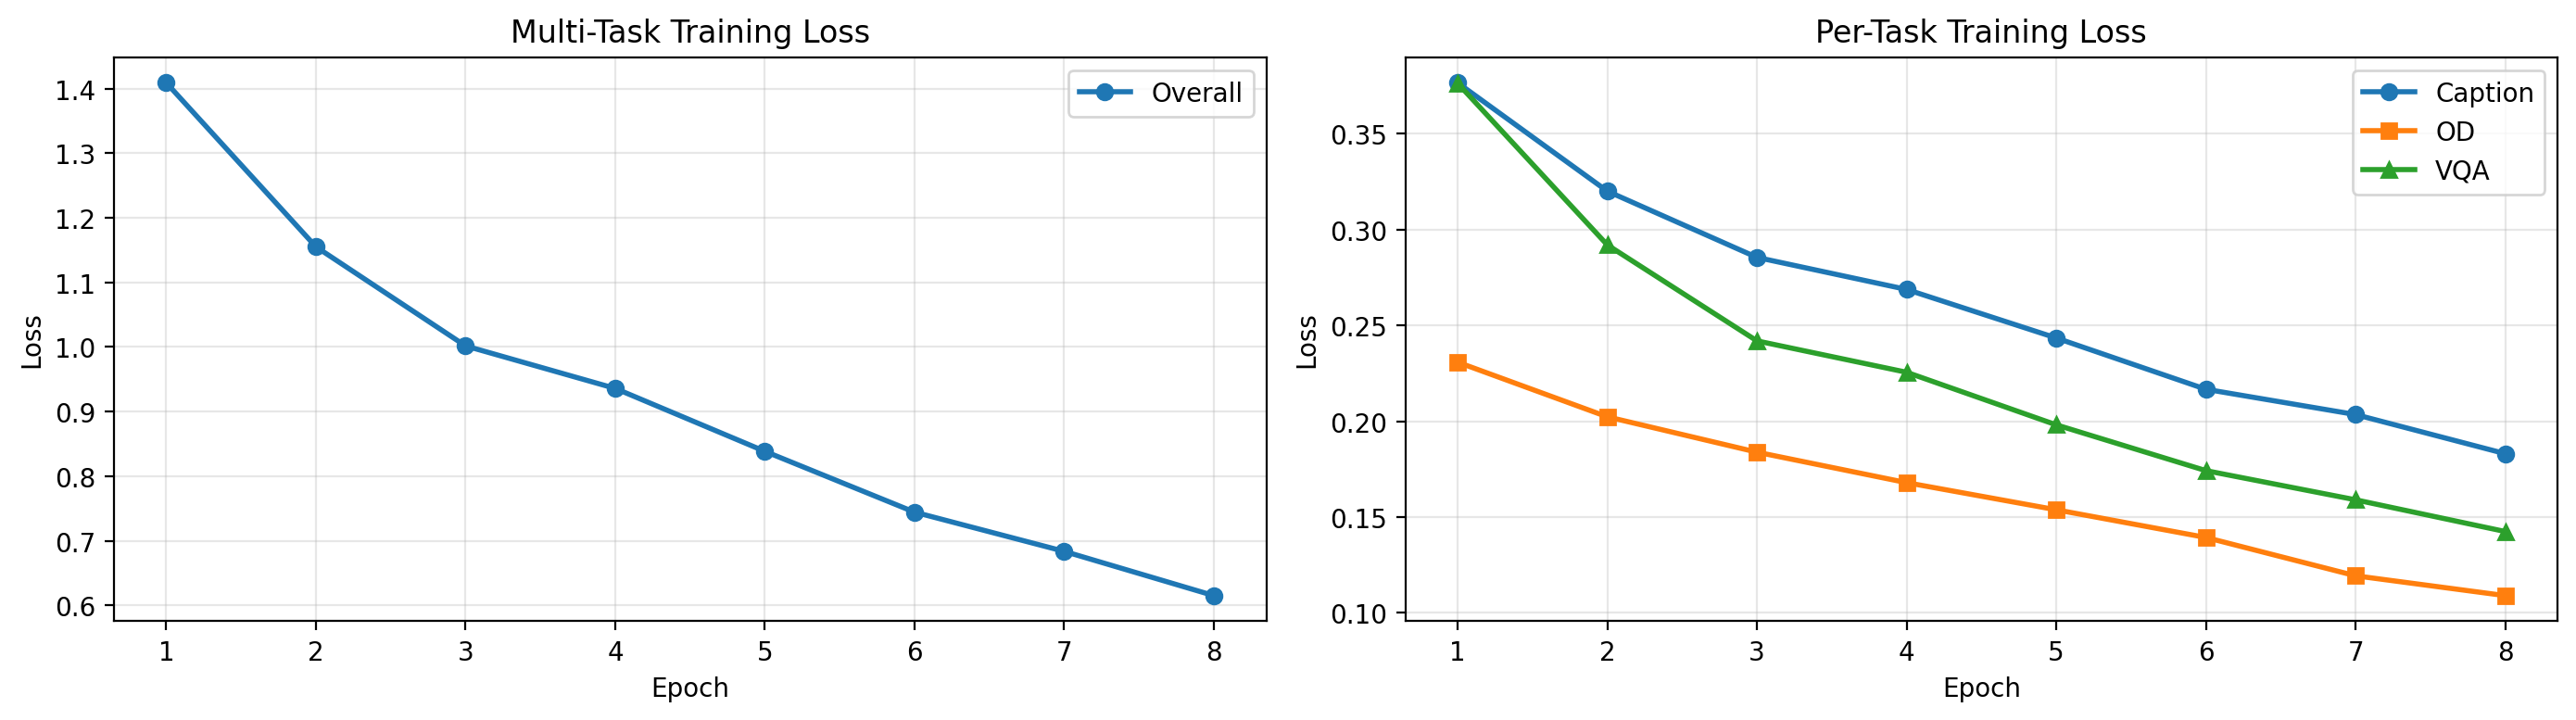

In [12]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Overall loss
ax1.plot(range(1, len(losses)+1), losses, marker='o', label='Overall', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Multi-Task Training Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Per-task losses
ax2.plot(range(1, len(losses)+1), task_losses['caption'], marker='o', label='Caption', linewidth=2)
ax2.plot(range(1, len(losses)+1), task_losses['object_detection'], marker='s', label='OD', linewidth=2)
ax2.plot(range(1, len(losses)+1), task_losses['vqa'], marker='^', label='VQA', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Per-Task Training Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Part 4: Evaluate on All Three Tasks

Test the multi-task model on each task to verify it can handle all three.

In [13]:
# Helper functions for generation

def generate_caption(model, image, image_processor, device):
    """Generate a caption."""
    model.eval()
    
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    response = model.generate(
        pixel_values,
        prompt="Describe this image.",
        max_new_tokens=40,
        temperature=0.7,
        do_sample=True,
    )
    
    if "Describe this image." in response:
        return response.split("Describe this image.")[-1].strip()
    return response


def generate_od_response(model, image, image_processor, device):
    """Generate object detection JSON."""
    model.eval()
    
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    response = model.generate(
        pixel_values,
        prompt="What objects are in this image? Output as JSON.",
        max_new_tokens=150,
        temperature=0.3,
        do_sample=True,
    )
    
    return response


def generate_vqa_answer(model, image, question, image_processor, device):
    """Generate VQA answer."""
    model.eval()
    
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    prompt = f"Question: {question} Answer:"
    
    response = model.generate(
        pixel_values,
        prompt=prompt,
        max_new_tokens=10,
        temperature=1.0,
        do_sample=False,
    )
    
    if "Answer:" in response:
        answer = response.split("Answer:")[-1].strip()
    else:
        answer = response
    
    # Clean up
    answer = answer.split('.')[0].strip()
    words = answer.split()
    if len(words) > 5:
        answer = ' '.join(words[:5])
    
    return answer

In [14]:
# Test Task 1: CAPTIONING
print("=" * 70)
print("TASK 1: IMAGE CAPTIONING")
print("=" * 70)

caption_test_indices = [1000, 1005, 1010]  # Outside training set
for idx in caption_test_indices:
    if idx >= len(caption_dataset):
        idx = idx % len(caption_dataset)
    
    sample = caption_dataset[idx]
    image = sample['image']
    gt_caption = sample['caption_0']
    
    pred_caption = generate_caption(vlm, image, image_processor, device)
    
    print(f"\nImage {idx}:")
    print(f"  Predicted: {pred_caption}")
    print(f"  GT:        {gt_caption}")

TASK 1: IMAGE CAPTIONING

Image 0:
  Predicted: Boys in their underwear raise their boys on the ocean 's surface .
  GT:        Boys with their backs against an incoming wave .

Image 5:
  Predicted: An older man standing by a brick building holding a small stone tower .
  GT:        A man dressed like a rockstar poses in front of a brick wall .

Image 10:
  Predicted: Two children are playing on monkey bars in the yard .
  GT:        A child wearing a white shirt hangs from the playground equipment .


In [15]:
# Test Task 2: OBJECT DETECTION
print("\n" + "=" * 70)
print("TASK 2: OBJECT DETECTION")
print("=" * 70)

# Load test set
od_test = load_dataset('Francesco/animals-ij5d2', split='test')

for idx in [0, 5]:
    if idx >= len(od_test):
        continue
    
    sample = od_test[idx]
    image = sample['image']
    gt_json = create_od_json(sample['objects'], sample['width'], sample['height'], od_category_names)
    
    pred_response = generate_od_response(vlm, image, image_processor, device)
    
    print(f"\nTest Image {idx}:")
    print(f"  Predicted: {pred_response[:150]}...")
    print(f"  GT:        {gt_json[:150]}...")


TASK 2: OBJECT DETECTION

Test Image 0:
  Predicted: What objects are in this image? Output as JSON. {"objects": [{"label": "cow", "bbox": [0.014, 0.022, 0.977, 0.975]}, {"label": "cow", "bbox": [0.575, ...
  GT:        {"objects": [{"label": "cow", "bbox": [0.202, 0.455, 0.618, 0.545]}, {"label": "cow", "bbox": [0.186, 0.416, 0.146, 0.142]}, {"label": "cow", "bbox": ...

Test Image 5:
  Predicted: What objects are in this image? Output as JSON. {"objects": [{"label": "chicken", "bbox": [0.289, 0.475, 0.247, 0.456]}, {"label": "person", "bbox": [...
  GT:        {"objects": [{"label": "person", "bbox": [0.341, 0.278, 0.252, 0.722]}, {"label": "person", "bbox": [0.562, 0.291, 0.126, 0.335]}, {"label": "person",...


In [16]:
# Test Task 3: VQA
print("\n" + "=" * 70)
print("TASK 3: VISUAL QUESTION ANSWERING")
print("=" * 70)

# Load more VQA samples for testing
vqa_test_stream = load_dataset('lmms-lab/VQAv2', split='validation', streaming=True)
vqa_test_samples = []
for i, sample in enumerate(vqa_test_stream):
    if i < 1000:  # Skip training samples
        continue
    if i >= 1010:
        break
    vqa_test_samples.append(sample)

for i, sample in enumerate(vqa_test_samples[:5]):
    image = sample['image']
    question = sample['question']
    gt_answer = get_most_common_answer(sample['answers'])
    
    pred_answer = generate_vqa_answer(vlm, image, question, image_processor, device)
    
    print(f"\nQ: {question}")
    print(f"  Predicted: {pred_answer}")
    print(f"  GT:        {gt_answer}")


TASK 3: VISUAL QUESTION ANSWERING

Q: How big is the plane?
  Predicted: 4
  GT:        large

Q: Is the water rippling?
  Predicted: no
  GT:        no

Q: Is this good weather for their flight?
  Predicted: yes
  GT:        yes

Q: What color are the checkers on the wall?
  Predicted: white
  GT:        red and white

Q: How many pizza slices are there total?
  Predicted: 1
  GT:        8


## Part 5: Multi-Task Demonstration

Show all three tasks on the same image.

CAPTION:
  A girl is pulling a wagon with a boy on it behind her .

OBJECT DETECTION:
  What objects are in this image? Output as JSON. {"objects": [{"label": "cow", "bbox": [0.034, 0.344, 0.186, 0.166]}, {"label": "cow", "bbox": [0.727, 0.322, 0.202, 0.192]}, {"label": "cow", "bbox": [0...

VQA:
  Q: What animal is this?
  A: cows
  Q: What color is it?
  A: green
  Q: Is it indoors or outdoors?
  A: indoors


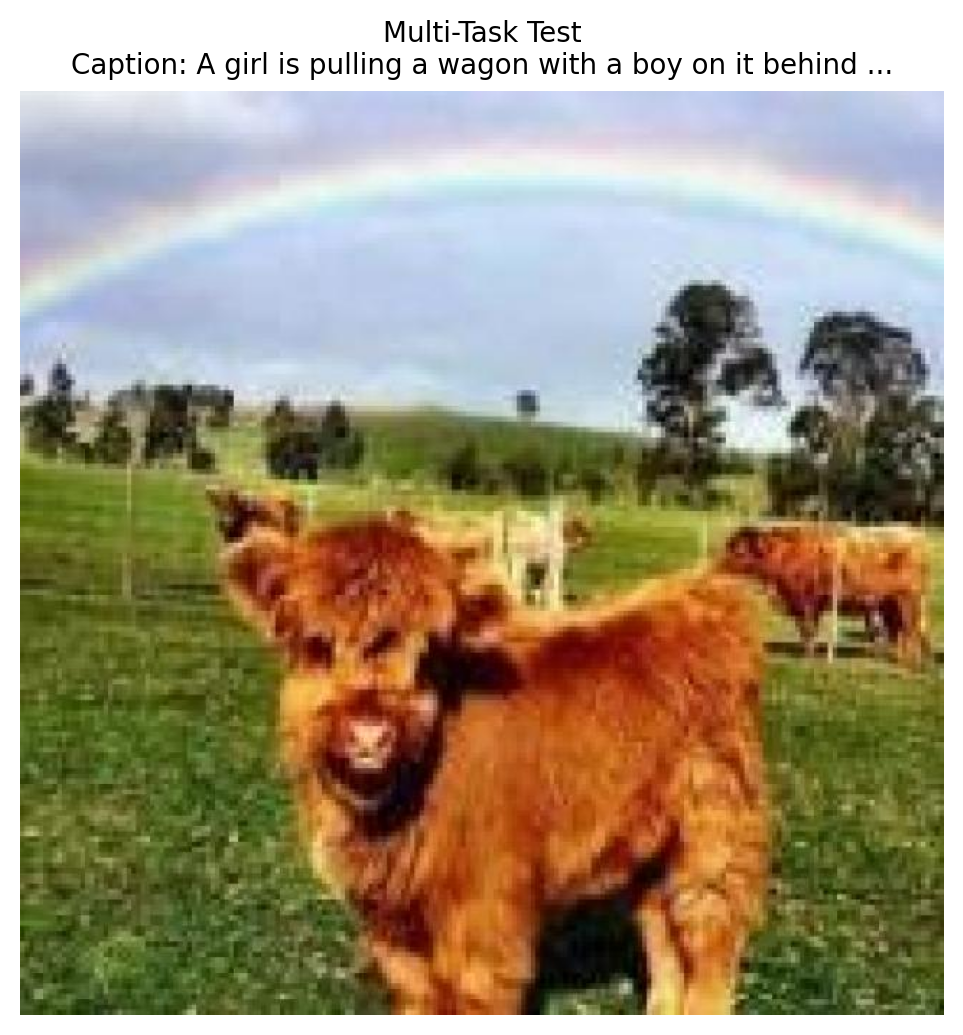

In [17]:
# Demonstrate all three tasks on one image
test_image = od_test[0]['image']

# Task 1: Caption
caption = generate_caption(vlm, test_image, image_processor, device)
print("CAPTION:")
print(f"  {caption}")

# Task 2: Object Detection
od_response = generate_od_response(vlm, test_image, image_processor, device)
print("\nOBJECT DETECTION:")
print(f"  {od_response[:200]}...")

# Task 3: VQA
questions = [
    "What animal is this?",
    "What color is it?",
    "Is it indoors or outdoors?"
]
print("\nVQA:")
for q in questions:
    answer = generate_vqa_answer(vlm, test_image, q, image_processor, device)
    print(f"  Q: {q}")
    print(f"  A: {answer}")

# Show the image
plt.figure(figsize=(6, 6))
plt.imshow(test_image)
plt.title(f"Multi-Task Test\nCaption: {caption[:50]}...", fontsize=10)
plt.axis('off')
plt.show()

## Part 6: Save Multi-Task Model

In [18]:
# Save the multi-task model
save_dir = "mini-vlm-multitask"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'projector_state_dict': vlm.projector.state_dict(),
    'language_model_state_dict': vlm.language_model.state_dict(),
    'config': {
        'vision_model_name': vision_model_name,
        'lm_model_name': lm_model_name,
        'vision_dim': vision_dim,
        'language_dim': language_dim,
    },
    'multitask_config': {
        'tasks': ['caption', 'object_detection', 'vqa'],
        'od_category_names': od_category_names,
    }
}, f"{save_dir}/mini_vlm_multitask.pt")

tokenizer.save_pretrained(f"{save_dir}/tokenizer")
image_processor.save_pretrained(f"{save_dir}/image_processor")

print(f"Multi-task model saved to {save_dir}/")
print(f"Contents: {os.listdir(save_dir)}")

Multi-task model saved to mini-vlm-multitask/
Contents: ['tokenizer', 'mini_vlm_multitask.pt', 'image_processor']


## Summary

We successfully created a **unified multi-task VLM** that handles:

### Three Tasks in One Model

1. **Image Captioning** - Natural language descriptions
2. **Object Detection** - Structured JSON with bounding boxes
3. **Visual Question Answering** - Short factual answers

### What We Did

1. Started from caption-trained model
2. Created multi-task dataset (2400 samples total)
3. Trained with task-specific prompts
4. Evaluated on all three tasks

### Key Insights

- **Task prompts** guide the model to different output formats
- **Shared vision encoder** learns representations useful for all tasks
- **Multi-task training** can improve generalization
- **Single model** is more practical than three separate models

### Model Evolution

```
Base Models (ViT + SmolLM)
    │
    └── Caption Training
            │
            ├── OD Fine-tuning (specialized)
            ├── VQA Fine-tuning (specialized)
            └── Multi-Task Fine-tuning (unified) ← This notebook
```

### Comparison: Specialized vs Multi-Task

| Approach | Pros | Cons |
|----------|------|------|
| **Specialized** | Better per-task performance | 3 models to deploy/maintain |
| **Multi-Task** | 1 model, shared learning | Slightly lower per-task accuracy |

### Limitations

- Small model (135M parameters)
- Limited training data per task
- No task-specific optimization
- Educational - not production-ready

### Next Steps

1. **Add more tasks** - image editing, visual grounding, OCR
2. **Task routing** - automatically detect task from prompt
3. **Larger models** - scale to SmolLM-1.7B or Qwen2-VL
4. **Better datasets** - use COCO, Visual Genome, etc.
5. **Task balancing** - adjust sampling ratios per task

## GPU Memory Management

If you need to free up GPU memory after running this notebook (especially important when running multiple notebooks in sequence), use these commands:

In [19]:
# Method 1: Delete models and clear cache
# This releases GPU memory allocated to model weights and intermediate tensors

# Delete the model components
del vlm
del vision_encoder
del language_model
del projector

# Clear PyTorch's GPU cache
import gc
gc.collect()  # Run Python garbage collector first
torch.cuda.empty_cache()  # Then clear CUDA cache

print("GPU memory cleared!")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory cleared!
GPU memory allocated: 0.02 GB
GPU memory reserved: 0.04 GB
